# 2. Major Predictors for the Ability to Induce Chills
Question: What variables (Demographic, Openness, Absorption, or Spiritual triggers) are the major predictors for the ability to induce chills?


In [2]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier



from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

In [3]:
cleaned_data = pd.read_csv('cleanedAweExperienceSurveyResponses.csv')
print(cleaned_data.head)

<bound method NDFrame.head of               timestamp age_range    env_growth                    worldview  \
0     4/9/2026 11:42:15     19-21      Suburban           Atheist/Naturalist   
1     4/9/2026 11:42:37     19-21      Suburban           Atheist/Naturalist   
2     4/9/2026 11:44:34     19-21  Rural/Remote           Atheist/Naturalist   
3     4/9/2026 11:46:07     19-21      Suburban  Spiritual but not Religious   
4     4/9/2026 11:46:22     19-21  Highly urban           Atheist/Naturalist   
..                  ...       ...           ...                          ...   
96    4/30/2026 8:34:43     25-30      Suburban  Spiritual but not Religious   
97    4/30/2026 8:37:52     22-24      Suburban           Religious/Theistic   
98    4/30/2026 9:04:22     25-30  Highly urban  Spiritual but not Religious   
99   4/30/2026 19:23:50     25-30      Suburban           Atheist/Naturalist   
100  4/30/2026 20:22:34     25-30  Highly urban           Atheist/Naturalist   

    activ

In [4]:
# 1. Prepare Data & Handle Missing Values
# Drop rows where the target is NaN
df_model = cleaned_data.dropna(subset=['chills_ablity_3']).copy()

# 2. Prepare Features
demo_features = ['age_range', 'env_growth', 'worldview', 'activity_primary', 
                 'gender_identity', 'edu_level', 'income_bracket', 'socioec_status', 'college_type']
awe_features = [c for c in df_model.columns if c.startswith('awe_scale_')]
trigger_features = [c for c in df_model.columns if 'trigger_' in c]

feature_cols = demo_features + awe_features + trigger_features
X_raw = df_model[feature_cols]

# One-hot encode categorical demographics
X_encoded = pd.get_dummies(X_raw, columns=demo_features, drop_first=True)

# Drop columns that might be leaky
X_encoded = X_encoded.drop(columns=[c for c in X_encoded.columns if 'chills' in c.lower()], errors='ignore')

# --- FIX: Fill NaNs in features with the median of each column ---
X_encoded = X_encoded.fillna(X_encoded.median())

y_3way = df_model['chills_ablity_3']

In [5]:
# 3. Train/Test Split (80/20)

# Configuration
n_iterations = 10
accuracies = []
print(f"Running {n_iterations} iterations...\n")

# X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_3way, test_size=0.2, random_state=42, stratify=y_3way)

# # 4. Scale Features
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# # 5. Fit Lasso (L1) Logistic Regression
# # solver='saga' supports multinomial loss with L1
# lasso_model = LogisticRegression(penalty='l1', solver='saga', multi_class='multinomial', max_iter=5000, random_state=42, C=0.5)
# lasso_model.fit(X_train_scaled, y_train)

# # 6. Evaluate
# y_pred = lasso_model.predict(X_test_scaled)
# print('Accuracy:', accuracy_score(y_test, y_pred))
# print('\nClassification Report:\n', classification_report(y_test, y_pred))

# # 7. Extract Feature Weights
# coef_df = pd.DataFrame(lasso_model.coef_, columns=X_encoded.columns, index=lasso_model.classes_).T
# coef_df['Absolute_Max_Weight'] = coef_df.abs().max(axis=1)
# top_predictors = coef_df.sort_values(by='Absolute_Max_Weight', ascending=False).head(20)

for i in range(n_iterations):
    # 3. Train/Test Split (80/20) 
    # Use 'i' or another varying seed to ensure different splits each time
    X_train, X_test, y_train, y_test = train_test_split(
        X_encoded, y_3way, test_size=0.2, random_state=i, stratify=y_3way
    )

    # 4. Scale Features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # 5. Fit Lasso (L1) Logistic Regression
    lasso_model = LogisticRegression(
        penalty='l1', 
        solver='saga', 
        multi_class='multinomial', 
        max_iter=5000, 
        random_state=i, 
        C=0.5
    )
    lasso_model.fit(X_train_scaled, y_train)

    # 6. Evaluate
    y_pred = lasso_model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    
    # Optional: print progress
    # print(f"Run {i+1} Accuracy: {acc:.4f}")

# Report Results
mean_accuracy = np.mean(accuracies)
std_accuracy = np.std(accuracies)

print("-" * 30)
print(f"Average Accuracy over {n_iterations} runs: {mean_accuracy:.4f}")
print(f"Standard Deviation: {std_accuracy:.4f}")
print("-" * 30)

# 7. Extract Feature Weights (from the last run as an example)
coef_df = pd.DataFrame(lasso_model.coef_, columns=X_encoded.columns, index=lasso_model.classes_).T
coef_df['Absolute_Max_Weight'] = coef_df.abs().max(axis=1)
top_predictors = coef_df.sort_values(by='Absolute_Max_Weight', ascending=False).head(20)
print("\nTop 20 Predictors from the final run:")
print(top_predictors[['Absolute_Max_Weight']])

Running 10 iterations...



/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in ve

------------------------------
Average Accuracy over 10 runs: 0.3400
Standard Deviation: 0.1020
------------------------------

Top 20 Predictors from the final run:
                                              Absolute_Max_Weight
trigger_spiritual_1                                      0.584063
trigger_spiritual_5                                      0.526546
trigger_interpersonal_2                                  0.489252
trigger_spiritual_3                                      0.482109
env_growth_Near large bodies of water/Nature             0.463554
socioec_status_Upper middle class                        0.433734
activity_primary_Student Clubs                           0.432851
awe_scale_9                                              0.379059
trigger_spiritual_6                                      0.362534
age_range_22-24                                          0.362251
activity_primary_Work                                    0.333822
edu_level_High school Diploma/GED         

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in ve

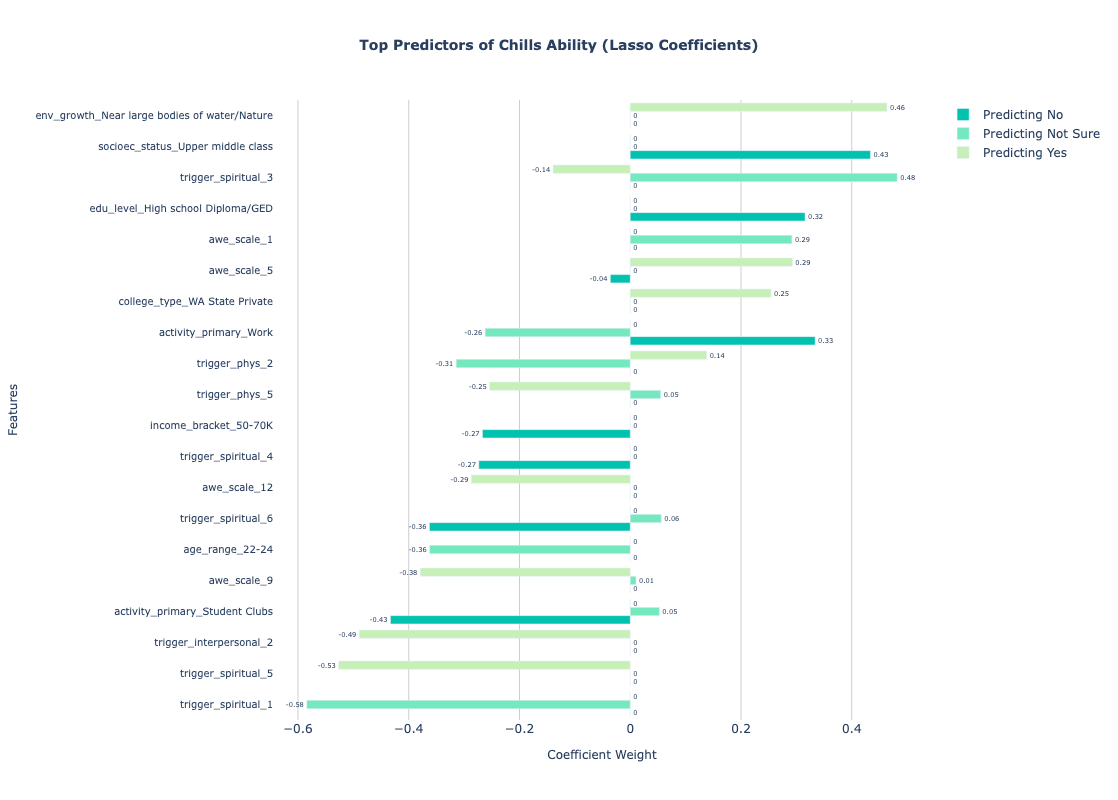


Top 10 Predictors by Absolute Weight:
                                              Absolute_Max_Weight
trigger_spiritual_1                                      0.584063
trigger_spiritual_5                                      0.526546
trigger_interpersonal_2                                  0.489252
trigger_spiritual_3                                      0.482109
env_growth_Near large bodies of water/Nature             0.463554
socioec_status_Upper middle class                        0.433734
activity_primary_Student Clubs                           0.432851
awe_scale_9                                              0.379059
trigger_spiritual_6                                      0.362534
age_range_22-24                                          0.362251


In [41]:
# 8. Visualize Top Predictors
import plotly.graph_objects as go

pheno_colors = ["#00C2AE", "#74E8BF", "#C7F0B9"]

fig = go.Figure()
# Loop through classes and assign colors from your palette
for i, label in enumerate(lasso_model.classes_):
    # Get the weights for this specific class
    weights = top_predictors[label]
    
    fig.add_trace(go.Bar(
        y=top_predictors.index,
        x=weights,
        name=f'Predicting {label}',
        orientation='h',
        marker_color=pheno_colors[i % len(pheno_colors)],
        # Static Text Labels
        text=weights.round(2),
        textposition='outside', # Forces labels outside the bars for consistent reading
        cliponaxis=False,       # Ensures labels aren't cut off at the edge of the plot
        # Disable Hover
        hoverinfo='skip',        # Completely removes the hover tooltip interaction
    ))

fig.update_layout(
    # Titles - bolded, fontsize 14
    title={
        'text': "<b>Top Predictors of Chills Ability (Lasso Coefficients)</b>",
        'font': {'size': 14},
        'x': 0.5,
        'xanchor': 'center'
    },
    barmode='group',
    # Axis Labels - fontsize 12
    yaxis={
        'categoryorder': 'total ascending',
        'tickfont': {'size': 10}, # Smaller ticks to fit all 20 predictors
        'title': {'text': 'Features', 'font': {'size': 12}}
    },
    xaxis={
        'title': {'text': 'Coefficient Weight', 'font': {'size': 12}},
        # Grid Lines - color grey, weight 0.4
        'showgrid': True,
        'gridcolor': 'grey',
        'gridwidth': 0.4
    },
    height=800,
    margin=dict(l=200), # Extra margin so feature names don't get cut off
    plot_bgcolor='#FFFFFF', # Clean background to keep grid lines subtle
    legend={'font': {'size': 12}}
)

fig.show()

print('\nTop 10 Predictors by Absolute Weight:')
print(top_predictors[['Absolute_Max_Weight']].head(10))